In [42]:
import sys 
import zipfile

import cv2
import numpy as np
import onnxruntime as ort
import matplotlib.pyplot as plt
from deepface import DeepFace

2025-07-14 21:54:37.603819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752544477.616267  506307 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752544477.621239  506307 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752544477.633888  506307 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752544477.633907  506307 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752544477.633908  506307 computation_placer.cc:177] computation placer alr

In [ ]:
!wget -P tflite2onnx https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task

In [10]:
def extract_tflite(task_path):
    with zipfile.ZipFile(task_path, 'r') as z:
        for f in z.namelist():
            z.extract(f, path="/home/amos/programs/Visage/notebooks/tf")

In [ ]:
extract_tflite("tf/face_landmarker.task")

I'm not including the subsequent step here because it involves

In [16]:
!python -m tf2onnx.convert --saved-model saved_model --output mesh.onnx

2025-07-14 21:41:52.691808: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752543712.708137  529973 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752543712.713490  529973 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752543712.727404  529973 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752543712.727437  529973 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752543712.727457  529973 computation_placer.cc:177] computation placer alr

In [18]:
onnx_path = "mesh.onnx"
session = ort.InferenceSession(onnx_path)

In [19]:
# Get input and output names
input_names = [inp.name for inp in session.get_inputs()]
output_names = [out.name for out in session.get_outputs()]

print("Inputs:", input_names)
print("Outputs:", output_names)

Inputs: ['input_12']
Outputs: ['Identity', 'Identity_1', 'Identity_2']


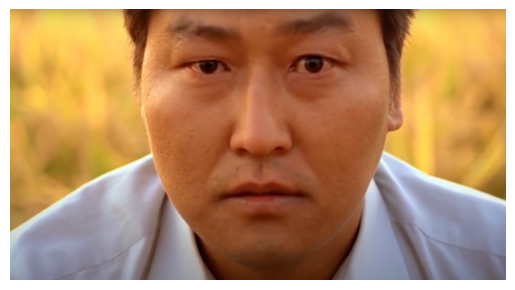

In [112]:
img_orig = cv2.imread("mom.jpg")
h, w = img_orig.shape[:2]
img_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')  
plt.show()

In [97]:
faces = DeepFace.extract_faces(img_rgb)
face = faces[0]['facial_area']
face

{'x': 412,
 'y': 0,
 'w': 1172,
 'h': 1079,
 'left_eye': (1177, 222),
 'right_eye': (790, 231)}

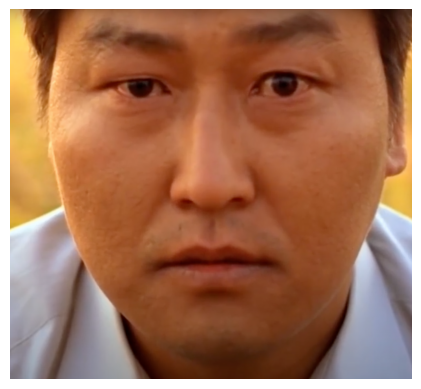

In [113]:
x1 = face['x']
y1 = face['y']
x2 = x1 + face['w']
y2 = y1 + face['h']
f = img_rgb[y1:y2, x1:x2]
plt.imshow(f)
plt.axis('off')  
plt.show()

In [118]:
resized = cv2.resize(img_rgb, (256, 256))
scale_x = w / 256
scale_y = h / 256

img_float = resized.astype(np.float32)
img_float /= 255.0

print(scale_x, scale_y)

7.734375 4.21875


In [100]:
outputs = session.run(output_names, {input_names[0]: np.expand_dims(img_float, axis=0)})

In [101]:
print(len(outputs))
output = outputs[0]
output.shape

3


(1, 1, 1, 1434)

In [102]:
output_squeezed = np.squeeze(output)
landmarks = output_squeezed.reshape(478, 3)
landmarks.shape

(478, 3)

In [122]:
landmarks = landmarks[:, :2]
landmarks.shape

(478, 2)

In [126]:
h, w = img_orig.shape[:2]
hh, ww = resized.shape[:2]
scaling = np.array([w/ww, h/hh])
scaling

array([7.734375, 4.21875 ])

In [127]:
scaled = scaling * landmarks
scaled

array([[1026.57990217,  657.0994091 ],
       [1009.9480927 ,  513.89963865],
       [1017.03537941,  562.13820219],
       [ 972.71590948,  403.11770082],
       [1007.00698614,  478.4075439 ],
       [1007.29258776,  436.04626894],
       [1011.44466877,  325.02904773],
       [ 730.55258811,  277.17672229],
       [1013.41000915,  212.09701896],
       [1014.75646734,  167.62823582],
       [1010.1979351 ,   63.02669898],
       [1026.97549582,  672.35954762],
       [1024.96165037,  689.20577288],
       [1021.62081957,  702.95134306],
       [1018.27810049,  718.16172123],
       [1015.99399567,  734.29707527],
       [1014.35202241,  754.73904848],
       [1010.03365517,  775.42016745],
       [1014.72318649,  802.04413891],
       [1012.86099315,  538.12455654],
       [ 984.20812905,  542.92903662],
       [ 568.99477601,  171.57515466],
       [ 842.15289474,  311.58052683],
       [ 805.76441646,  314.75408435],
       [ 765.73026896,  316.01936817],
       [ 709.39611733,  2

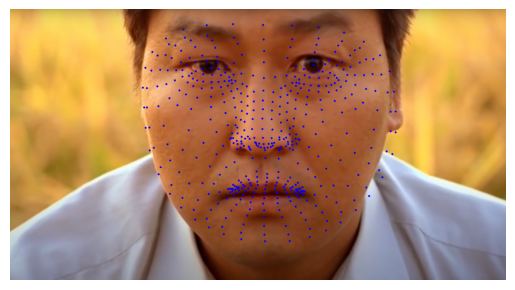

In [130]:
drawn = img_rgb.copy()
for i in range(scaled.shape[0]):
    x, y = [int(x) for x in scaled[i]]
    cv2.circle(drawn, (x, y), radius=4, color=(0, 0, 255), thickness=-1)
plt.imshow(drawn)
plt.axis('off')  
plt.show()